170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 52ms/step - accuracy: 0.4033 - loss: 1.6424 - val_accuracy: 0.5986 - val_loss: 1.1409
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.6200 - loss: 1.0795 - val_accuracy: 0.6473 - val_loss: 1.0191
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.6793 - loss: 0.9216 - val_accuracy: 0.6700 - val_loss: 0.9468
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 42ms/step - accuracy: 0.7159 - loss: 0.8161 - val_accuracy: 0.7004 - val_loss: 0.8775
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 66s 42ms/step - accuracy: 0.7542 - loss: 0.7118 - val_accuracy: 0.6945 - val_loss: 0.8974
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.7831 - loss: 0.6226 - val_accuracy: 0.6835 - val_loss: 0.9580
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 44ms/step - accuracy: 0.8076 - loss: 0.5464 - val_accuracy: 0.7074 - val_loss: 0.8886
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.8336 -

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 60ms/step - accuracy: 0.3022 - loss: 1.8777 - val_accuracy: 0.5022 - val_loss: 1.3741
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 61ms/step - accuracy: 0.4598 - loss: 1.5019 - val_accuracy: 0.5656 - val_loss: 1.2023
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 60ms/step - accuracy: 0.4957 - loss: 1.4042 - val_accuracy: 0.6125 - val_loss: 1.0973
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 62ms/step - accuracy: 0.5244 - loss: 1.3295 - val_accuracy: 0.5891 - val_loss: 1.1572
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 94s 60ms/step - accuracy: 0.5473 - loss: 1.2727 - val_accuracy: 0.5988 - val_loss: 1.1172
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 61ms/step - accuracy: 0.5586 - loss: 1.2445 - val_accuracy: 0.6005 - val_loss: 1.1024
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 59ms/step - accuracy: 0.5701 - loss: 1.2068 - val_accuracy: 0.6395 - val_loss: 1.0025
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 93s 60ms/step - accuracy: 0.5840 - loss: 1

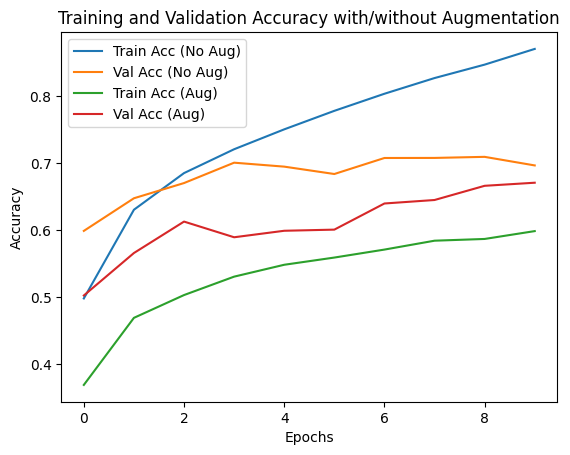

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar10

# Load CIFAR-10 Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize Data
x_train = x_train / 255.0
x_test = x_test / 255.0

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(x_train)

# Define CNN Model
def create_model():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
        MaxPooling2D(2,2),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Train Model Without Augmentation
model_no_aug = create_model()
history_no_aug = model_no_aug.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10, batch_size=32)

# Train Model With Augmentation
model_aug = create_model()
history_aug = model_aug.fit(datagen.flow(x_train, y_train, batch_size=32), validation_data=(x_test, y_test), epochs=10)

# Plot Training and Validation Accuracy
plt.plot(history_no_aug.history['accuracy'], label='Train Acc (No Aug)')
plt.plot(history_no_aug.history['val_accuracy'], label='Val Acc (No Aug)')
plt.plot(history_aug.history['accuracy'], label='Train Acc (Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val Acc (Aug)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy with/without Augmentation')
plt.show()
